# 4 · Features nuevas: limpieza de datos, NDVI, ERA5 (suelo/heladas), agro

### 4.0 — La mayor mejora del proyecto: LIMPIEZA DE DATOS
El panel tenía **25% de filas duplicadas** (explosión cartesiana de lat/lon por un
join que ignoró la provincia) y la etiqueta `z_rinde` estaba corrompida por agrupar
departamentos homónimos de distintas provincias. Corregirlo (dedup + clave
provincia, en `data.py`) **subió a TODOS los modelos +0.09 a +0.14 PR-AUC** — más
que cualquier cambio de modelo.

In [1]:
import explib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

### 4.1 — Features satelitales / reanálisis
Buscamos features que capturen el ~70% de anomalías **sin firma climática** (ver
notebook 05). Tres fuentes nuevas, todas extraídas por departamento×campaña con
Google Earth Engine:
- **NDVI-AVHRR** (1981+): vigor vegetal.
- **ERA5-Land**: humedad de suelo (estado inicial / "inercia") + días de helada.
- **Agronómicas**: ventana crítica + balance hídrico (derivadas de columnas existentes).

Efecto sobre el modelo SOTA (VAE) y el IForest, **con test sets emparejados**:

In [2]:
explib.show(explib.tbl_features())

,features,VAE_seedens,IForest,nota
0,"base (limpio, sin features extra)",0.592,0.511,VAE / IForest
1,+ NDVI-AVHRR (1981+),0.561,0.503,redundante con clima
2,+ agronómicas (ventana crítica),0.422,0.421,"ayuda IForest, perjudica VAE"
3,+ ERA5 (suelo + heladas),0.580,0.542,"ayuda IForest, perjudica VAE"


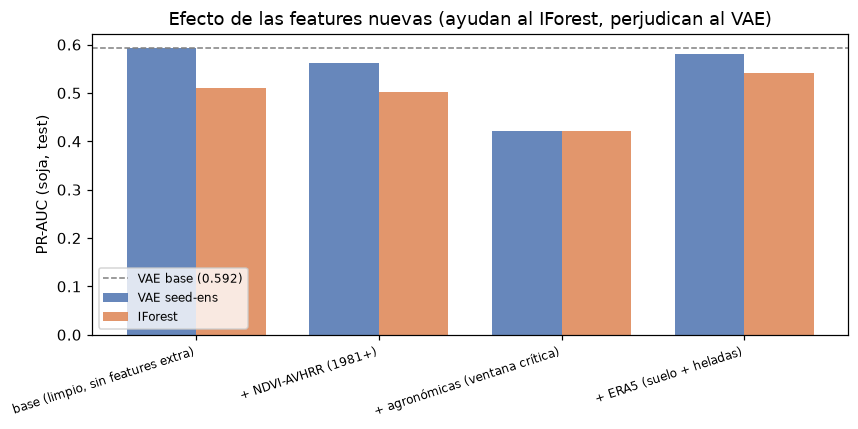

In [3]:
import numpy as np
t = explib.tbl_features()
x = np.arange(len(t)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, t["VAE_seedens"], w, label="VAE seed-ens", color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, t["IForest"], w, label="IForest", color="#DD8452", alpha=0.85)
ax.axhline(0.592, ls="--", color="gray", lw=1, label="VAE base (0.592)")
ax.set_xticks(x); ax.set_xticklabels(t["features"], rotation=18, ha="right", fontsize=8)
ax.set_ylabel("PR-AUC (soja, test)"); ax.legend(fontsize=8)
ax.set_title("Efecto de las features nuevas (ayudan al IForest, perjudican al VAE)")
plt.tight_layout(); plt.show()

**Conclusión:** ninguna feature extra supera al base **con el VAE** — lo
*perjudican* (diluyen el `recon_prob`). Ayudan **modestamente al IForest** (tolera
features extra) pero IForest+ERA5 (0.542) sigue debajo del VAE base (0.592).

**Lección de método (un artefacto cazado):** un primer resultado ERA5 dio 0.642 —
era un **artefacto**: `frost_days`=0 en el norte (nunca hiela) → varianza-cero por
depto → la normalización tiraba el 34% de los departamentos → test set sesgado y más
fácil. Se corrigió con fallback a *std global* en `_normalize_per_depto`. Con test
sets emparejados, el efecto real es el de la tabla. **Siempre validar que los test
sets coincidan antes de comparar.**